In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Shape : {df.shape}')
df.head()

Shape : (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [40]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## 1. Suppression des features inutiles
Ces colonnes ont une valeur unique pour tous les employés → aucune information prédictive.

In [41]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)
print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Shape après suppression : (1470, 31)


## 2. Encodage de la variable cible
`Attrition` (Yes/No) → binaire (1/0)

In [42]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print('Distribution de la variable cible :')
print(df['Attrition'].value_counts())
print(f"\nTaux d'attrition : {df['Attrition'].mean()*100:.1f}%")

Distribution de la variable cible :
Attrition
0    1233
1     237
Name: count, dtype: int64

Taux d'attrition : 16.1%


## 3. Encodage des variables catégorielles
- **Label Encoding** → variables binaires (2 modalités)
- **One-Hot Encoding** → variables nominales (3+ modalités)

In [43]:
# Label Encoding
binary_cols = ['Gender', 'OverTime']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'{col} encodé : {df[col].unique()}')

# One-Hot Encoding
nominal_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f'\nShape après encodage : {df.shape}')
df.head(3)

Gender encodé : [0 1]
OverTime encodé : [1 0]

Shape après encodage : (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True


## 4. Création de nouvelles features

In [44]:
# Taux de promotion (ancienneté / temps depuis dernière promotion)
df['PromotionRate'] = df['YearsAtCompany'] / (df['YearsSinceLastPromotion'] + 1)

# Stabilité dans le rôle actuel
df['RoleStabilityRate'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1)

# Expérience moyenne par entreprise
df['AvgYearsPerCompany'] = df['TotalWorkingYears'] / (df['NumCompaniesWorked'] + 1) #Enlever le nombre of companies ca sert a rien

# Score de satisfaction global (moyenne des 4 scores)
df['SatisfactionScore'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction'] +
    df['WorkLifeBalance']
) / 4

# Salaire rapporté au niveau de poste
df['IncomePerLevel'] = df['MonthlyIncome'] / df['JobLevel']

# Flag : employé senior (>10 ans d'expérience)
df['IsSenior'] = (df['TotalWorkingYears'] >= 10).astype(int)

# Flag : bloqué dans son poste (pas de promotion depuis 3+ ans)
df['StuckInRole'] = (df['YearsSinceLastPromotion'] >= 3).astype(int)

print('Nouvelles features créées ✓')
df[['PromotionRate','RoleStabilityRate','AvgYearsPerCompany',
    'SatisfactionScore','IncomePerLevel','IsSenior','StuckInRole']].describe().round(2)

Nouvelles features créées ✓


,PromotionRate,RoleStabilityRate,AvgYearsPerCompany,SatisfactionScore,IncomePerLevel,IsSenior,StuckInRole
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,3.12,0.48,4.19,2.73,2973.80,0.51,0.25
std,3.12,0.27,4.04,0.51,770.64,0.50,0.44
min,0.00,0.00,0.00,1.00,1009.00,0.00,0.00
25%,1.00,0.33,1.60,2.50,2394.12,0.00,0.00
50%,2.00,0.50,3.00,2.75,2856.50,1.00,0.00
75%,4.00,0.67,5.00,3.00,3478.83,1.00,1.00
max,33.00,0.88,38.00,4.00,4999.00,1.00,1.00


## 5. Vérification des valeurs manquantes et infinis

In [45]:
# Valeurs manquantes
print('Valeurs manquantes :', df.isnull().sum().sum())

# Valeurs infinies (issues des divisions)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
print('Valeurs infinies remplacées ✓')
print('Dataset propre ✓')

Valeurs manquantes : 0
Valeurs infinies remplacées ✓
Dataset propre ✓


## 6. Normalisation (StandardScaler)
Appliquée aux variables numériques continues — exclut la cible et les binaires.

In [46]:
exclude_cols = ['Attrition', 'Gender', 'OverTime', 'IsSenior', 'StuckInRole']
ohe_cols = [c for c in df.columns if df[c].nunique() == 2 and c not in exclude_cols]

cols_to_scale = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in exclude_cols + ohe_cols
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f'Colonnes normalisées ({len(cols_to_scale)}) :')
print(cols_to_scale)

Colonnes normalisées (27) :
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PromotionRate', 'RoleStabilityRate', 'AvgYearsPerCompany', 'SatisfactionScore', 'IncomePerLevel']


## 7. Visualisation des nouvelles features vs Attrition

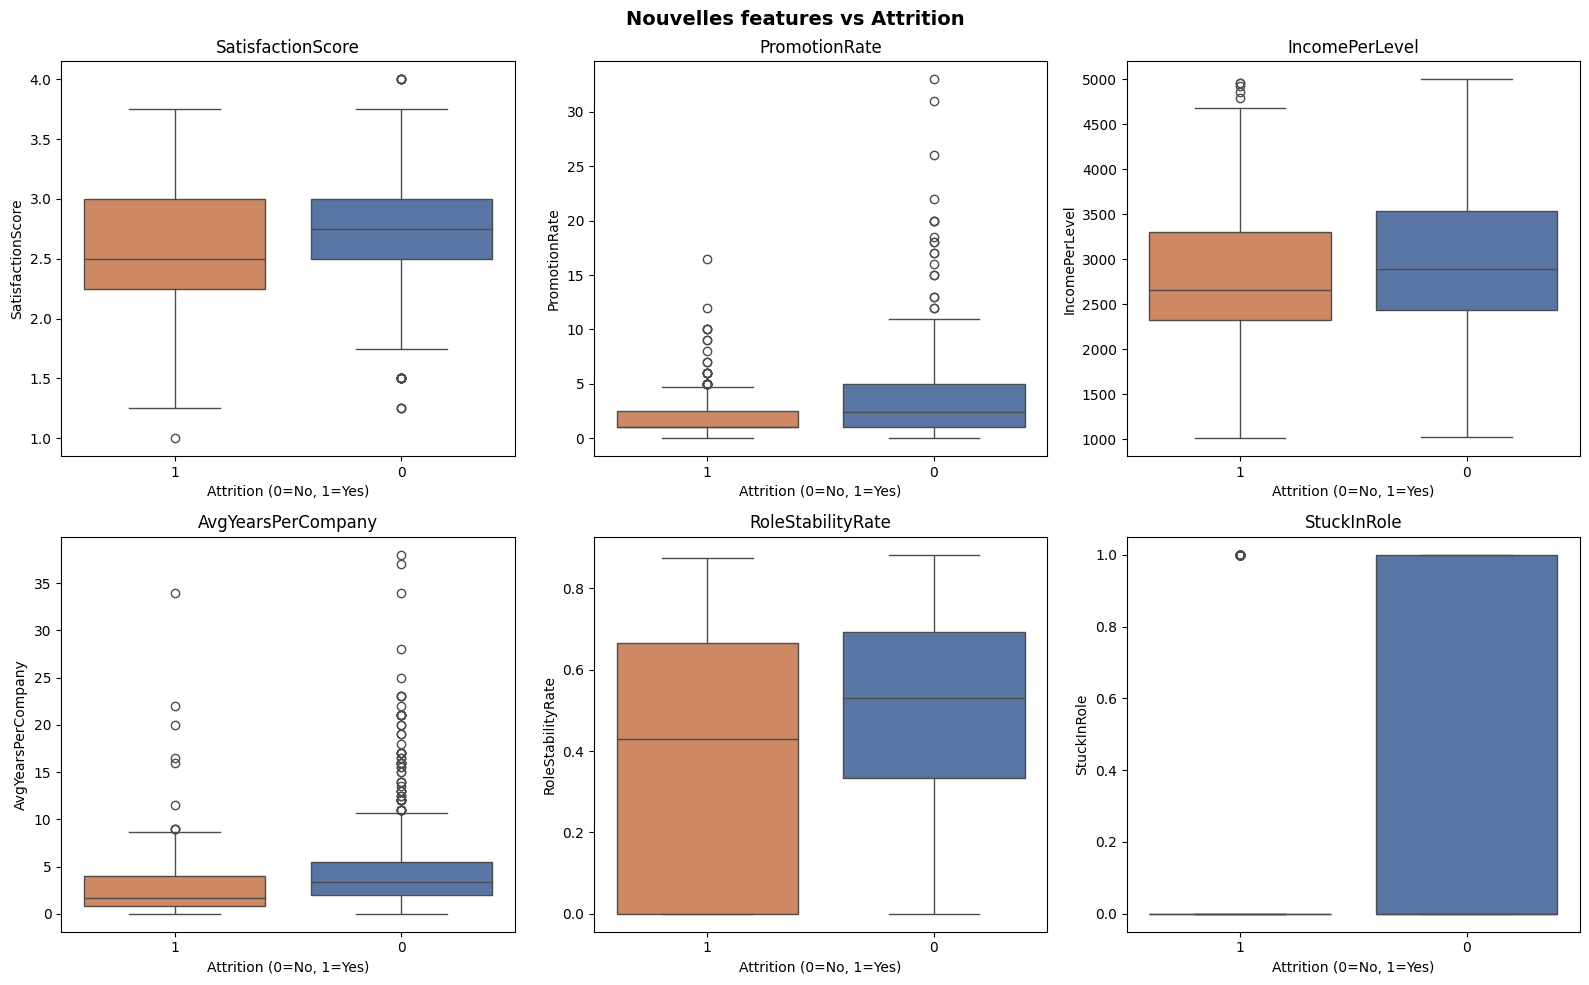

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Nouvelles features vs Attrition', fontsize=14, fontweight='bold')

plot_features = ['SatisfactionScore', 'PromotionRate', 'IncomePerLevel',
                 'AvgYearsPerCompany', 'RoleStabilityRate', 'StuckInRole']

df_plot = df.copy()
df_plot['Attrition'] = df_plot['Attrition'].astype(str)

for ax, feat in zip(axes.flatten(), plot_features):
    sns.boxplot(data=df_plot, x='Attrition', y=feat, ax=ax,
                palette={'0': '#4C72B0', '1': '#DD8452'})
    ax.set_title(feat)
    ax.set_xlabel('Attrition (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('new_features_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
#explique l utilité des 7 features (en oral)


## 8. Sauvegarde du dataset final

In [48]:
# Dataset non normalisé (pour interprétation et clustering)
df.to_csv('df_engineered.csv', index=False)

# Dataset normalisé (pour les modèles ML supervisés)
df_scaled.to_csv('df_scaled.csv', index=False)

print(f'df_engineered.csv sauvegardé — Shape : {df.shape}')
print(f'df_scaled.csv sauvegardé     — Shape : {df_scaled.shape}')

df_engineered.csv sauvegardé — Shape : (1470, 52)
df_scaled.csv sauvegardé     — Shape : (1470, 52)


In [49]:
#un graphe avant le nettoyage
#un graphe apres le nettoyage
#un graphe de modeles / ceci pour les livrables de 3 graphes 
#il faut que les graphes soient commentés+

# Deliverable 3 — Model Selection

### 0. Imports & chargement des données

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Chargement des datasets issus du D2
df = pd.read_csv('df_engineered.csv')
df_scaled = pd.read_csv('df_scaled.csv')

print(f'Shape df_engineered : {df.shape}')
print(f'Shape df_scaled     : {df_scaled.shape}')

Shape df_engineered : (1470, 52)
Shape df_scaled     : (1470, 52)


### 1. Préparation des données (supervisé)

In [51]:
# Séparation features / cible
X = df_scaled.drop(columns=['Attrition'])
y = df_scaled['Attrition']

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Taux attrition train : {y_train.mean()*100:.1f}%')
print(f'Taux attrition test  : {y_test.mean()*100:.1f}%')

Train : (1176, 51) | Test : (294, 51)
Taux attrition train : 16.2%
Taux attrition test  : 16.0%


### 2. Modèle 1 — Logistic Regression (baseline)
Modèle de référence interprétable. Gère le déséquilibre via class_weight='balanced'.

In [52]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294

AUC-ROC : 0.8064


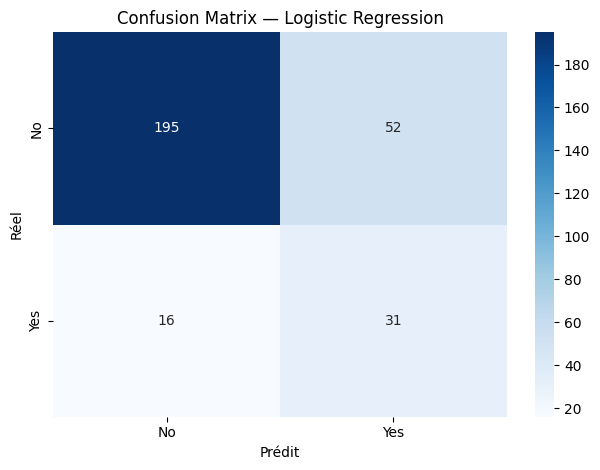

In [53]:
# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('cm_lr.png', dpi=150)
plt.show()

### 3. Modèle 2 — Random Forest
Modèle ensembliste robuste, gère la non-linéarité et fournit les feature importances.

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Grille de paramètres à explorer
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 10, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {rf_search.best_params_}")
print(f"Meilleur AUC-ROC (CV) : {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 227}
Meilleur AUC-ROC (CV) : 0.8030


In [55]:
# Utilisation du meilleur modèle trouvé
rf = rf_search.best_estimator_

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (après tuning) ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest (après tuning) ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       247
           1       0.40      0.30      0.34        47

    accuracy                           0.82       294
   macro avg       0.64      0.61      0.62       294
weighted avg       0.80      0.82      0.81       294

AUC-ROC : 0.7615


In [56]:
# Visualisation de l'impact du tuning
results = pd.DataFrame(rf_search.cv_results_)
top_results = results.nlargest(10, 'mean_test_score')[
    ['mean_test_score', 'std_test_score',
     'param_n_estimators', 'param_max_depth',
     'param_min_samples_split']
].round(4)

print("Top 10 configurations testées :")
top_results

Top 10 configurations testées :


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split
32,0.8030,0.0530,227,None,12
47,0.7980,0.0540,445,20,5
24,0.7978,0.0602,326,None,4
14,0.7974,0.0562,450,None,15
5,0.7972,0.0553,158,10,18
23,0.7969,0.0536,198,None,6
43,0.7967,0.0609,302,None,5
3,0.7963,0.0606,291,None,3
4,0.7962,0.0549,413,None,13
9,0.7958,0.0522,445,None,10


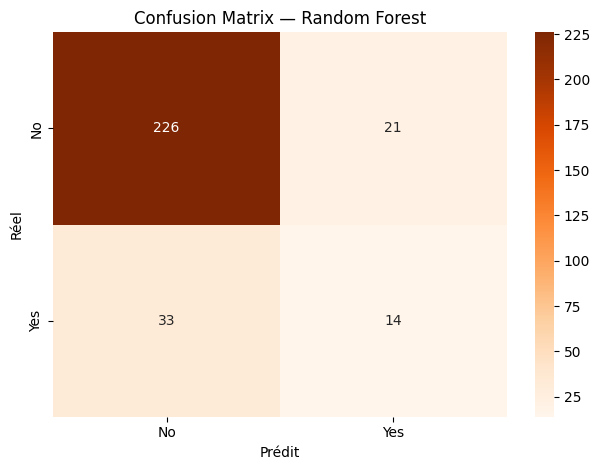

In [57]:
# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=150)
plt.show()


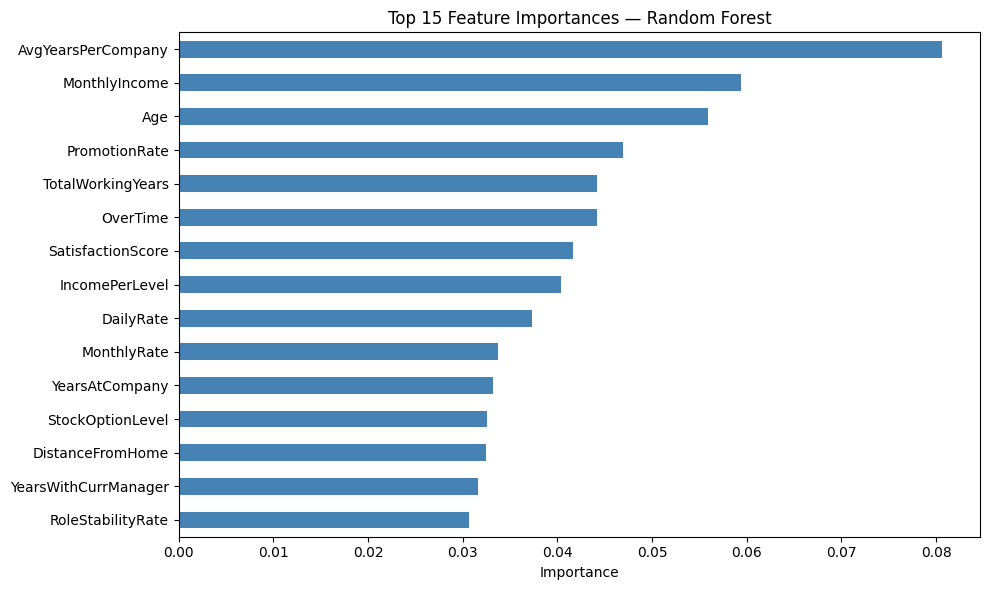

In [58]:
# Feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15)

top15.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

### 4. Comparaison supervisée — Courbes ROC

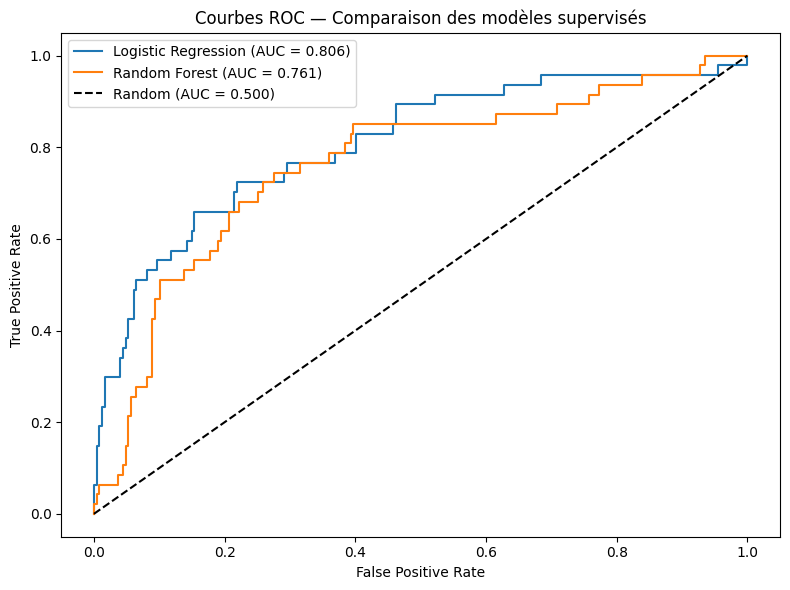

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — Comparaison des modèles supervisés')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## 5. Modèle 3 — K-Means (non supervisé)
Segmentation des employés en profils homogènes. On utilise df_scaled sans la variable cible.

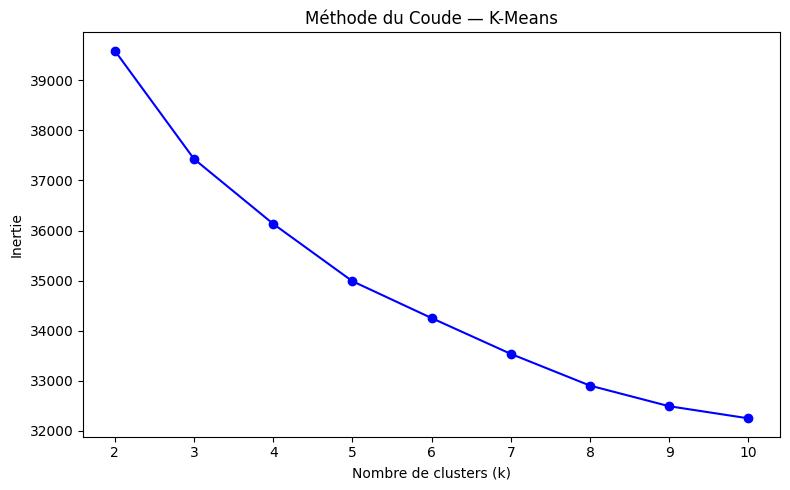

In [60]:
# Données pour le clustering (sans la variable cible)
X_cluster = df_scaled.drop(columns=['Attrition'])

# Méthode du coude pour choisir k
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude — K-Means')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('elbow_kmeans.png', dpi=150)
plt.show()

In [61]:
# Application de K-Means avec le k optimal (à ajuster selon le coude)
k_optimal = 4  # à modifier selon le graphique du coude

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

print(f'Distribution des clusters :')
print(df['Cluster'].value_counts().sort_index())
print(f"\nTaux d'attrition par cluster :")
print(df.groupby('Cluster')['Attrition'].mean().round(3))

Distribution des clusters :
Cluster
0    762
1    401
2    141
3    166
Name: count, dtype: int64

Taux d'attrition par cluster :
Cluster
0    0.218
1    0.110
2    0.071
3    0.102
Name: Attrition, dtype: float64


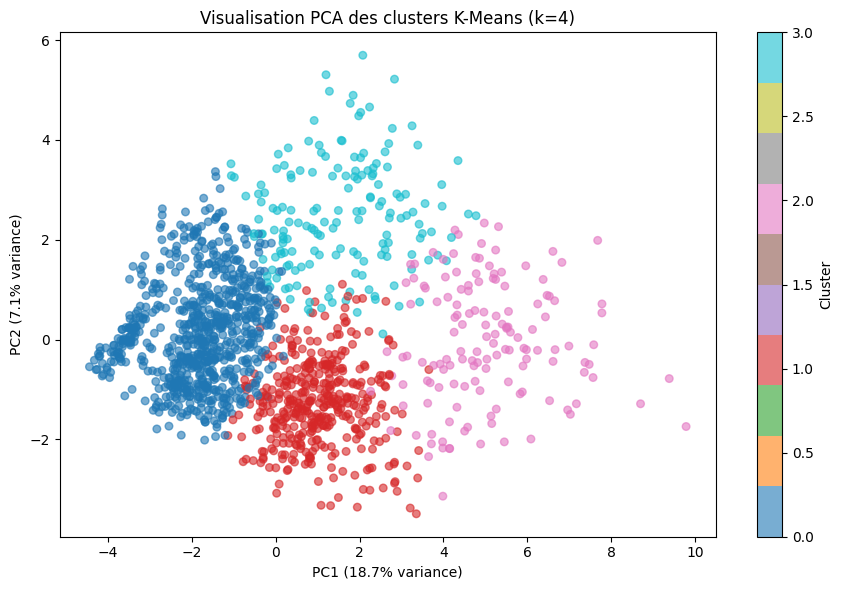

In [62]:
# Visualisation 2D des clusters via PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Visualisation PCA des clusters K-Means (k={k_optimal})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150)
plt.show()

In [63]:
# Profil moyen de chaque cluster (features non scalées)
profile_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'JobSatisfaction', 'OverTime', 'SatisfactionScore',
                'PromotionRate', 'Attrition']

cluster_profiles = df.groupby('Cluster')[profile_cols].mean().round(2)
print("Profil moyen par cluster :")
cluster_profiles

Profil moyen par cluster :


,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,OverTime,SatisfactionScore,PromotionRate,Attrition
Cluster,,,,,,,,
0,33.54,3841.59,3.38,2.70,0.29,2.72,2.29,0.22
1,35.95,5889.51,9.90,2.81,0.26,2.76,4.11,0.11
2,45.46,14787.99,20.84,2.68,0.26,2.72,5.06,0.07
3,47.55,13163.93,4.90,2.72,0.33,2.74,2.87,0.10


### 6. Sauvegarde des résultats

In [64]:
df.to_csv('df_with_clusters.csv', index=False)
print('df_with_clusters.csv sauvegardé ✓')

print("\n=== RÉSUMÉ DES PERFORMANCES ===")
print(f"Logistic Regression  — AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f} | F1 (Yes) : {f1_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest (tuné) — AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f} | F1 (Yes) : {f1_score(y_test, y_pred_rf):.4f}")
print(f"K-Means              — k={k_optimal} clusters | Taux attrition cluster 0 : {df[df['Cluster']==0]['Attrition'].mean()*100:.1f}%")
print(f"\nMeilleurs paramètres RF : {rf_search.best_params_}")

df_with_clusters.csv sauvegardé ✓

=== RÉSUMÉ DES PERFORMANCES ===
Logistic Regression  — AUC-ROC : 0.8064 | F1 (Yes) : 0.4769
Random Forest (tuné) — AUC-ROC : 0.7615 | F1 (Yes) : 0.3415
K-Means              — k=4 clusters | Taux attrition cluster 0 : 21.8%

Meilleurs paramètres RF : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 227}


# Deliverable 4 — Visualization

### 0. Imports & chargement des données

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Datasets
df_original = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_engineered = pd.read_csv('df_engineered.csv')
df_clusters = pd.read_csv('df_with_clusters.csv')

print(f'Original     : {df_original.shape}')
print(f'Engineered   : {df_engineered.shape}')
print(f'With clusters: {df_clusters.shape}')

Original     : (1470, 35)
Engineered   : (1470, 52)
With clusters: (1470, 53)


### 1. Visualisation — Données originales
Vue d'ensemble de l'attrition dans le dataset brut

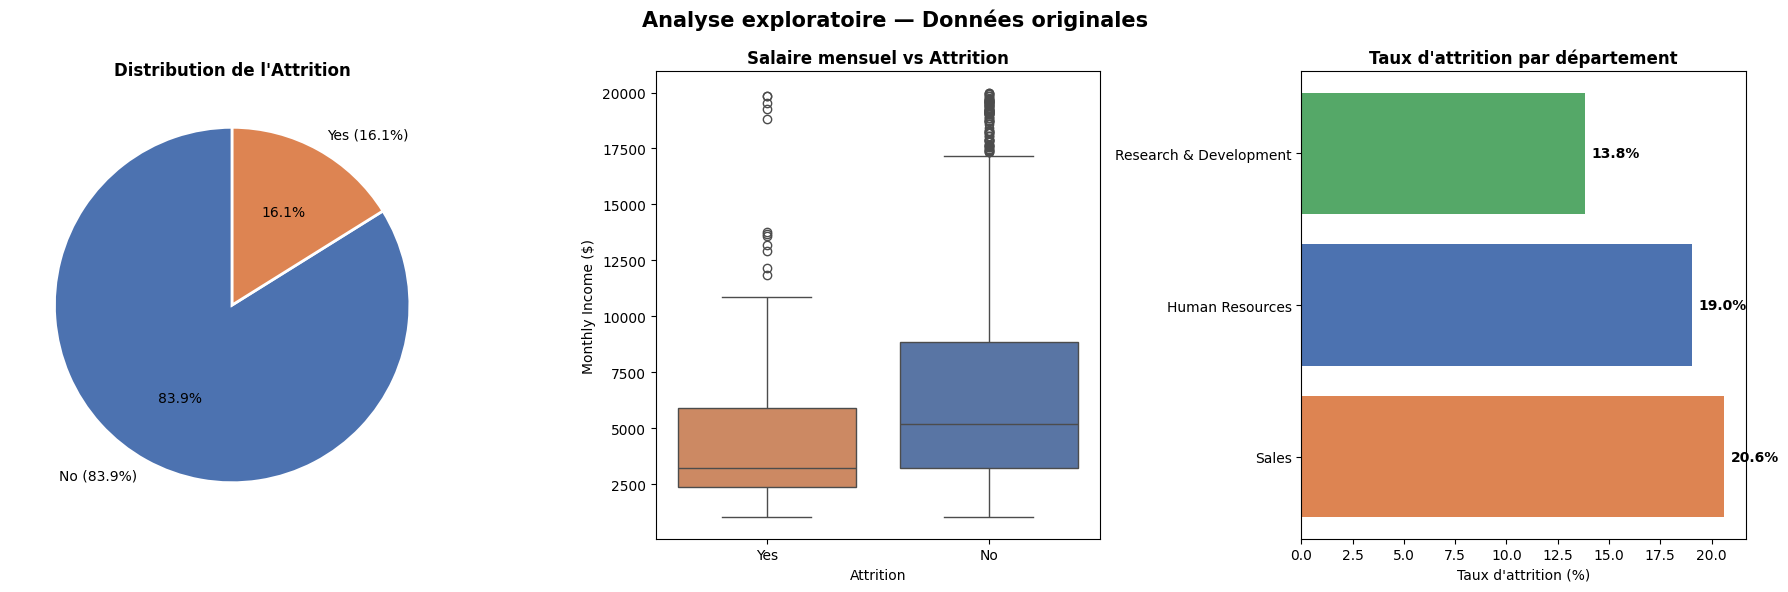

Plot 1 sauvegardé ✓


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analyse exploratoire — Données originales', fontsize=15, fontweight='bold')

# --- Plot 1 : Distribution Attrition ---
attrition_counts = df_original['Attrition'].value_counts()
colors = ['#4C72B0', '#DD8452']
axes[0].pie(attrition_counts, labels=['No (83.9%)', 'Yes (16.1%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribution de l\'Attrition', fontweight='bold')

# --- Plot 2 : MonthlyIncome vs Attrition ---
df_plot = df_original.copy()
sns.boxplot(data=df_plot, x='Attrition', y='MonthlyIncome', ax=axes[1],
            palette={'No': '#4C72B0', 'Yes': '#DD8452'})
axes[1].set_title('Salaire mensuel vs Attrition', fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income ($)')

# --- Plot 3 : Taux d'attrition par département ---
dept_attrition = df_original.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
dept_attrition.columns = ['Department', 'AttritionRate']
dept_attrition = dept_attrition.sort_values('AttritionRate', ascending=False)

bars = axes[2].barh(dept_attrition['Department'], dept_attrition['AttritionRate'],
                     color=['#DD8452', '#4C72B0', '#55A868'])
axes[2].set_title('Taux d\'attrition par département', fontweight='bold')
axes[2].set_xlabel('Taux d\'attrition (%)')
for bar, val in zip(bars, dept_attrition['AttritionRate']):
    axes[2].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('D4_plot1_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 sauvegardé ✓')

### 2. Visualisation — Données feature-engineered
Impact des nouvelles features créées au D2

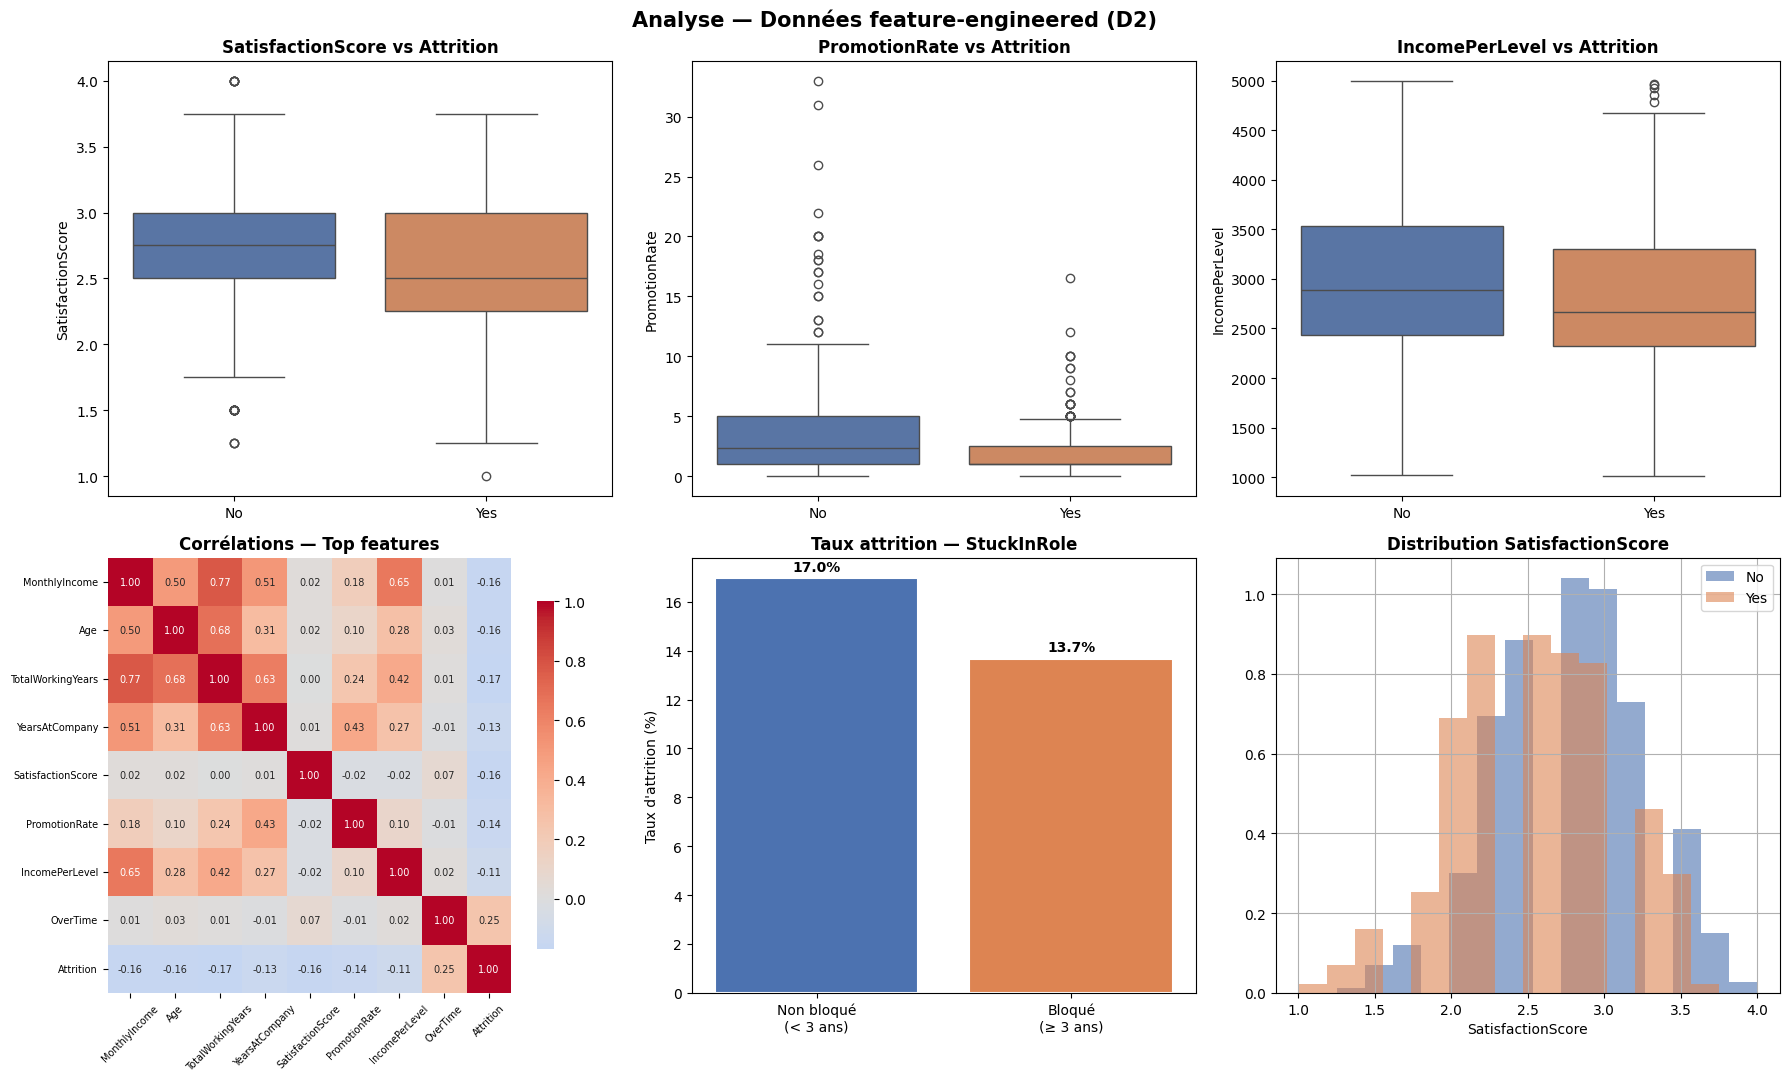

Plot 2 sauvegardé ✓


In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Analyse — Données feature-engineered (D2)', fontsize=15, fontweight='bold')

df_eng_plot = df_engineered.copy()
df_eng_plot['Attrition_label'] = df_eng_plot['Attrition'].map({1: 'Yes', 0: 'No'})

# --- Plot 1 : SatisfactionScore ---
sns.boxplot(data=df_eng_plot, x='Attrition_label', y='SatisfactionScore',
            ax=axes[0,0], palette={'No': '#4C72B0', 'Yes': '#DD8452'},
            order=['No', 'Yes'])
axes[0,0].set_title('SatisfactionScore vs Attrition', fontweight='bold')
axes[0,0].set_xlabel('')

# --- Plot 2 : PromotionRate ---
sns.boxplot(data=df_eng_plot, x='Attrition_label', y='PromotionRate',
            ax=axes[0,1], palette={'No': '#4C72B0', 'Yes': '#DD8452'},
            order=['No', 'Yes'])
axes[0,1].set_title('PromotionRate vs Attrition', fontweight='bold')
axes[0,1].set_xlabel('')

# --- Plot 3 : IncomePerLevel ---
sns.boxplot(data=df_eng_plot, x='Attrition_label', y='IncomePerLevel',
            ax=axes[0,2], palette={'No': '#4C72B0', 'Yes': '#DD8452'},
            order=['No', 'Yes'])
axes[0,2].set_title('IncomePerLevel vs Attrition', fontweight='bold')
axes[0,2].set_xlabel('')

# --- Plot 4 : Heatmap corrélations top features ---
top_features = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany',
                'SatisfactionScore', 'PromotionRate', 'IncomePerLevel',
                'OverTime', 'Attrition']
corr_matrix = df_engineered[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1,0], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
axes[1,0].set_title('Corrélations — Top features', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,0].tick_params(axis='y', rotation=0, labelsize=7)

# --- Plot 5 : StuckInRole vs Attrition ---
stuck_attrition = df_engineered.groupby('StuckInRole')['Attrition'].mean() * 100
axes[1,1].bar(['Non bloqué\n(< 3 ans)', 'Bloqué\n(≥ 3 ans)'],
               stuck_attrition.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
axes[1,1].set_title('Taux attrition — StuckInRole', fontweight='bold')
axes[1,1].set_ylabel('Taux d\'attrition (%)')
for i, val in enumerate(stuck_attrition.values):
    axes[1,1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# --- Plot 6 : Distribution SatisfactionScore ---
df_eng_plot[df_eng_plot['Attrition']==0]['SatisfactionScore'].hist(
    ax=axes[1,2], alpha=0.6, color='#4C72B0', label='No', bins=15, density=True)
df_eng_plot[df_eng_plot['Attrition']==1]['SatisfactionScore'].hist(
    ax=axes[1,2], alpha=0.6, color='#DD8452', label='Yes', bins=15, density=True)
axes[1,2].set_title('Distribution SatisfactionScore', fontweight='bold')
axes[1,2].set_xlabel('SatisfactionScore')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('D4_plot2_engineered.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 sauvegardé ✓')

### 3. Visualisation — Performance des modèles (D3)

In [70]:
# Recharger les données et réentraîner pour récupérer les probas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

df_scaled = pd.read_csv('df_scaled.csv')
X = df_scaled.drop(columns=['Attrition'])
y = df_scaled['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Random Forest (meilleurs paramètres du D3)
rf = RandomForestClassifier(n_estimators=227, max_depth=None, max_features='log2',
                             min_samples_leaf=4, min_samples_split=12,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Modèles entraînés ✓')

Modèles entraînés ✓


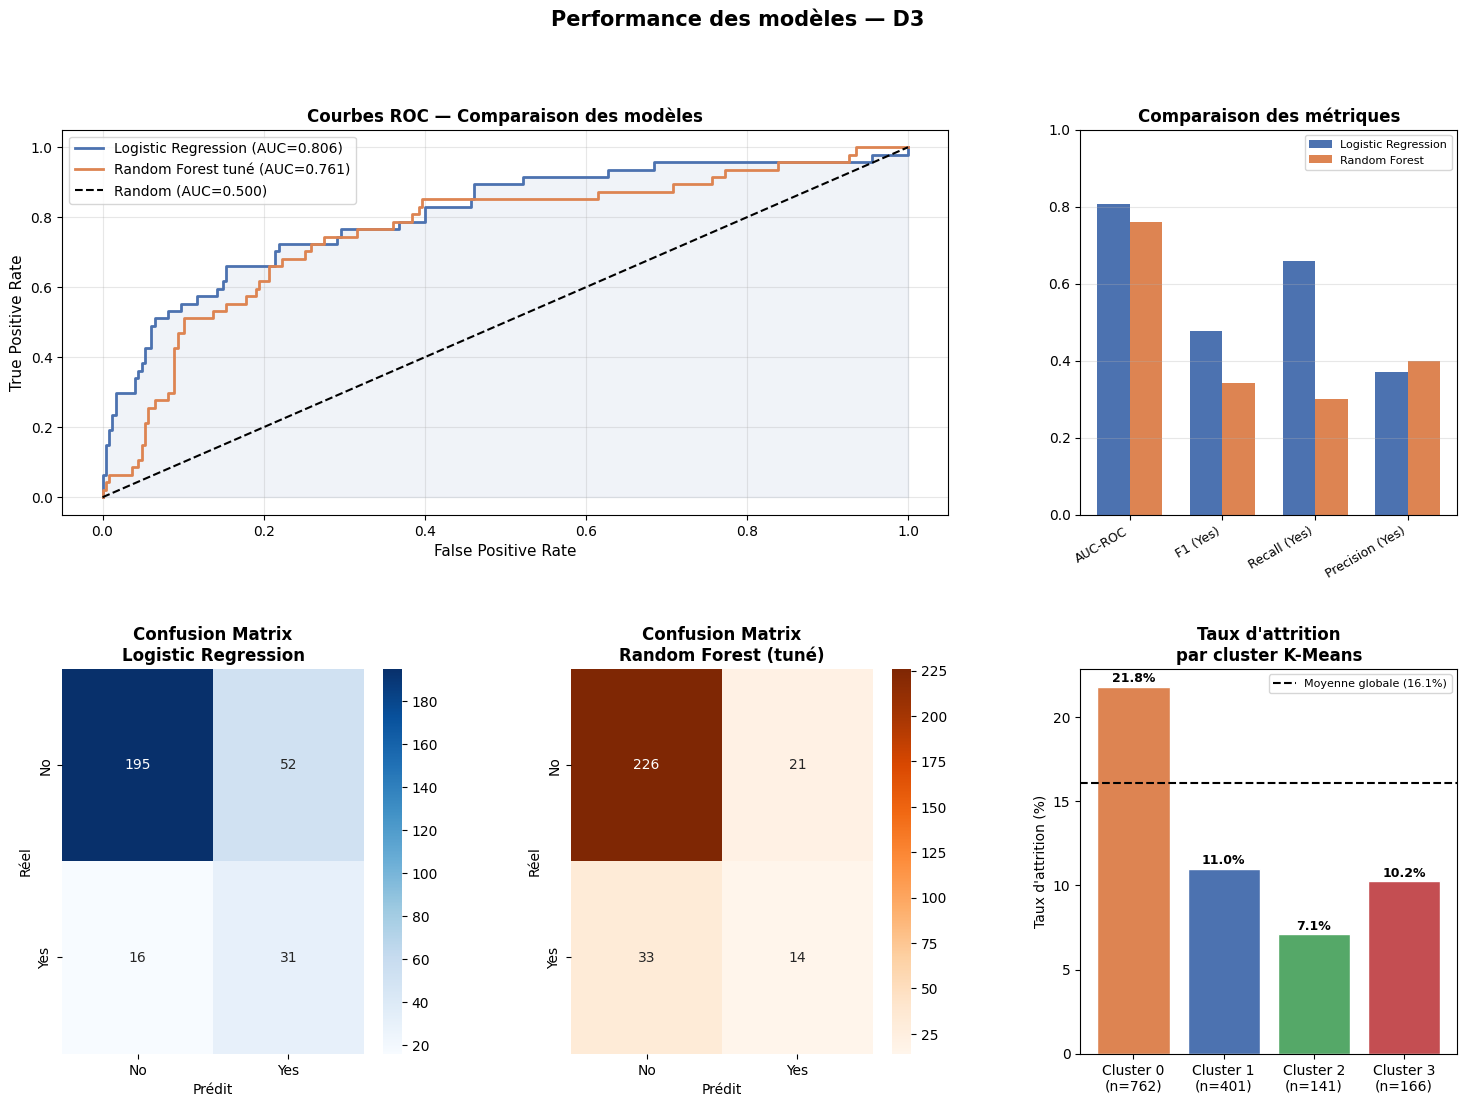

Plot 3 sauvegardé ✓


In [71]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Performance des modèles — D3', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Plot 1 : Courbes ROC ---
ax1 = fig.add_subplot(gs[0, :2])
for name, proba, color in [
    ('Logistic Regression (AUC=0.806)', y_proba_lr, '#4C72B0'),
    ('Random Forest tuné (AUC=0.761)', y_proba_rf, '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, color=color, lw=2, label=name)
ax1.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.500)')
ax1.fill_between(*roc_curve(y_test, y_proba_lr)[:2], alpha=0.08, color='#4C72B0')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Plot 2 : Barres comparatives métriques ---
ax2 = fig.add_subplot(gs[0, 2])
metrics = ['AUC-ROC', 'F1 (Yes)', 'Recall (Yes)', 'Precision (Yes)']
lr_scores = [0.8064, 0.4769, 0.66, 0.37]
rf_scores = [0.7615, 0.3415, 0.30, 0.40]
x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#4C72B0')
ax2.bar(x + width/2, rf_scores, width, label='Random Forest', color='#DD8452')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, rotation=30, ha='right', fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title('Comparaison des métriques', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# --- Plot 3 : Confusion Matrix LR ---
ax3 = fig.add_subplot(gs[1, 0])
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax3.set_title('Confusion Matrix\nLogistic Regression', fontweight='bold')
ax3.set_ylabel('Réel')
ax3.set_xlabel('Prédit')

# --- Plot 4 : Confusion Matrix RF ---
ax4 = fig.add_subplot(gs[1, 1])
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax4.set_title('Confusion Matrix\nRandom Forest (tuné)', fontweight='bold')
ax4.set_ylabel('Réel')
ax4.set_xlabel('Prédit')

# --- Plot 5 : Taux attrition par cluster ---
ax5 = fig.add_subplot(gs[1, 2])
cluster_attrition = df_clusters.groupby('Cluster')['Attrition'].mean() * 100
cluster_sizes = df_clusters['Cluster'].value_counts().sort_index()
colors_clusters = ['#DD8452', '#4C72B0', '#55A868', '#C44E52']
bars = ax5.bar([f'Cluster {i}\n(n={cluster_sizes[i]})' for i in range(4)],
               cluster_attrition.values, color=colors_clusters, edgecolor='white')
ax5.set_title('Taux d\'attrition\npar cluster K-Means', fontweight='bold')
ax5.set_ylabel('Taux d\'attrition (%)')
ax5.axhline(y=16.1, color='black', linestyle='--', linewidth=1.5, label='Moyenne globale (16.1%)')
ax5.legend(fontsize=8)
for bar, val in zip(bars, cluster_attrition.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.savefig('D4_plot3_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 sauvegardé ✓')

## ADS

In [72]:
#1. Validation croisée explicite
cv_scores = cross_val_score(lr, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"AUC-ROC moyen (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

AUC-ROC moyen (5-fold) : 0.8373 ± 0.0264


In [73]:
#2. Coefficients de la Logistic Regression
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

In [74]:
#3. Silhouette Score pour K-Means
from sklearn.metrics import silhouette_score
score = silhouette_score(X_cluster, df['Cluster'])
print(f"Silhouette Score (k=4) : {score:.4f}")

Silhouette Score (k=4) : 0.0892


In [75]:
#4. Seuil de décision ajusté (threshold tuning)
threshold = 0.3
y_pred_adjusted = (y_proba_lr >= threshold).astype(int)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.95      0.60      0.73       247
           1       0.28      0.83      0.42        47

    accuracy                           0.63       294
   macro avg       0.61      0.71      0.58       294
weighted avg       0.84      0.63      0.68       294



In [76]:
#5. Une cellule "Profil de l'employé type à risque"
# Caractéristiques moyennes des employés à risque (Attrition=1)
risk_profile = df_engineered[df_engineered['Attrition']==1][
    ['Age','MonthlyIncome','YearsAtCompany','OverTime',
     'SatisfactionScore','PromotionRate']
].mean().round(2)
print("Profil moyen de l'employé qui part :")
print(risk_profile)

Profil moyen de l'employé qui part :
Age                    33.61
MonthlyIncome        4787.09
YearsAtCompany          5.13
OverTime                0.54
SatisfactionScore       2.55
PromotionRate           2.12
dtype: float64


In [77]:
#6. Une cellule "Actions RH recommandées par cluster"
recommandations = {
    'Cluster 0 (21.8% attrition)': 'Augmentation rapide, plan de carrière, onboarding',
    'Cluster 1 (11.0% attrition)': 'Opportunités d\'évolution, formation',
    'Cluster 2 (7.1% attrition)':  'Fidélisation légère, reconnaissance',
    'Cluster 3 (10.2% attrition)': 'Réduction heures supp, équilibre pro/perso'
}

In [78]:
#7. ROI estimé de l'outil prédictif
# Coût moyen de remplacement = 1 salaire annuel
avg_salary = df_original['MonthlyIncome'].mean() * 12
tp = 31  # vrais positifs détectés par LR
saving_rate = 0.5  # on évite 50% des départs détectés
roi = tp * avg_salary * saving_rate
print(f"Économie potentielle estimée : ${roi:,.0f}/an")

Économie potentielle estimée : $1,209,545/an
